In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

In [2]:
hor0 = np.load("horizontal_thread_0_ana.npz")
hor1 = np.load("horizontal_thread_1_ana.npz")
# hor2 = np.load("horizontal_thread_2.npz")
ver0 = np.load("vertical_thread_0_ana.npz")
ver1 = np.load("vertical_thread_1_ana.npz")
# ver2 = np.load("vertical_thread_2.npz")

fiber = np.load("fiber_network.npz", allow_pickle=True)

In [3]:
horizontal_data = fiber["horizontal_data"]
vertical_data = fiber["vertical_data"]

In [4]:
rods_history = fiber["rods_history"]
rods_history = rods_history[0]
rod_history_unpacker = lambda rod_idx, t_idx: (
    rods_history[rod_idx]["position"][t_idx],
    rods_history[rod_idx]["radius"][t_idx],
    rods_history[rod_idx]["directors"][t_idx],
)

for rod_idx in range(4):
    inst_position, inst_radius, inst_directors = rod_history_unpacker(rod_idx, 0)

In [15]:
x = np.array(rods_history[0]["time"])
print(np.rint(x[-1]).astype(int))

10


In [ ]:
horizontal_data = horizontal_data[0]
vertical_data = vertical_data[0]

numpy.ndarray

KeyError: 'vertical_data is not a file in the archive'

In [19]:
hor0["position"].shape

(2000, 3, 101)

In [20]:
hor0["bending_energy"].shape

(999999,)

In [21]:
t1 = np.linspace(0, 10, 2000)
data1 = hor0["position"]
data2 = hor1["position"]
data3 = ver0["position"]
data4 = ver1["position"]
t2 = np.linspace(0, 10, 999999)

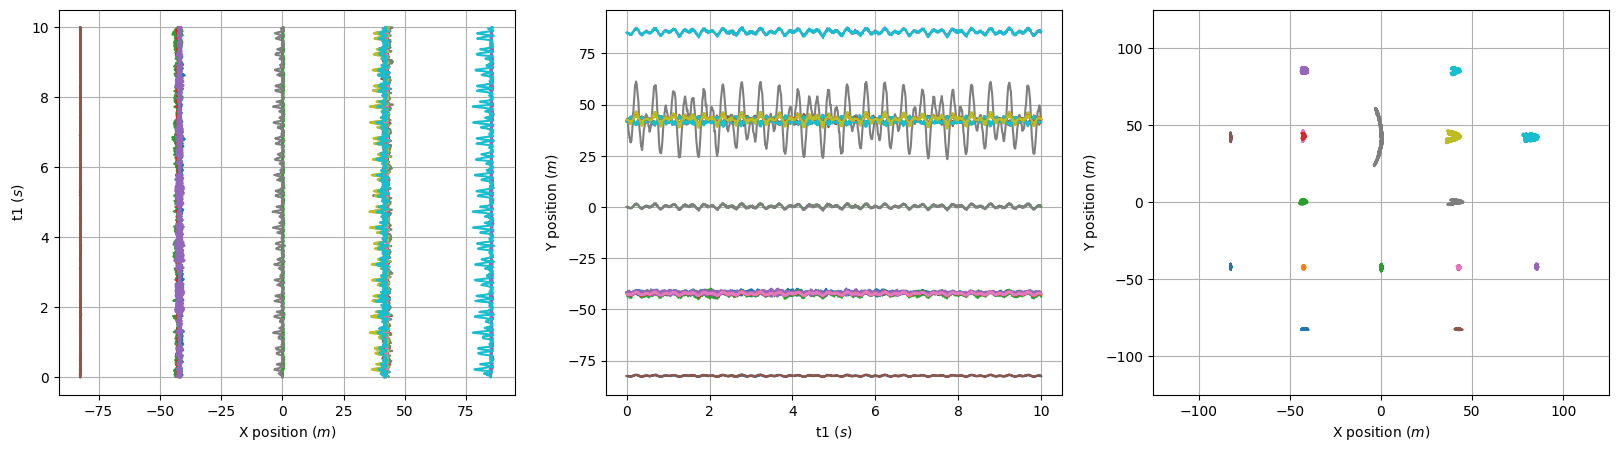

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
x = np.array([data1[..., 0, 17], data1[..., 0, 33], data1[..., 0, 50], data1[..., 0, 67], data1[..., 0, 84], 
     data2[..., 0, 17], data2[..., 0, 33], data2[..., 0, 50], data2[..., 0, 67], data2[..., 0, 84],
     data3[..., 0, 17], data3[..., 0, 33], data3[..., 0, 50], data3[..., 0, 67], data3[..., 0, 84], 
     data4[..., 0, 17], data4[..., 0, 33], data4[..., 0, 50], data4[..., 0, 67], data4[..., 0, 84]])
y = np.array([data1[..., 1, 17], data1[..., 1, 33], data1[..., 1, 50], data1[..., 1, 67], data1[..., 1, 84], 
     data2[..., 1, 17], data2[..., 1, 33], data2[..., 1, 50], data2[..., 1, 67], data2[..., 1, 84],
     data3[..., 1, 17], data3[..., 1, 33], data3[..., 1, 50], data3[..., 1, 67], data3[..., 1, 84], 
     data4[..., 1, 17], data4[..., 1, 33], data4[..., 1, 50], data4[..., 1, 67], data4[..., 1, 84]])
z = np.array([data1[..., 2, 17], data1[..., 2, 33], data1[..., 2, 50], data1[..., 2, 67], data1[..., 2, 84], 
     data2[..., 2, 17], data2[..., 2, 33], data2[..., 2, 50], data2[..., 2, 67], data2[..., 2, 84],
     data3[..., 2, 17], data3[..., 2, 33], data3[..., 2, 50], data3[..., 2, 67], data3[..., 2, 84], 
     data4[..., 2, 17], data4[..., 2, 33], data4[..., 2, 50], data4[..., 2, 67], data4[..., 2, 84]])
ax1.plot(x.T, t1)
# ax1.plot(data2[..., 0, 84].T, t1, 'k')
ax1.set_xlabel("X position ($m$)")
ax1.set_ylabel("t1 ($s$)")
ax1.grid(True)

ax2.plot(t1, y.T)
ax2.set_xlabel("t1 ($s$)")
ax2.set_ylabel("Y position ($m$)")
ax2.grid(True)

ax3.plot(x.T, y.T)
ax3.set_xlabel("X position ($m$)")
ax3.set_ylabel("Y position ($m$)")
ax3.set_xlim([-125, 125])
ax3.set_ylim([-125, 125])
ax3.grid(True)

plt.show()

In [23]:
for1 = ver0["int_forces"] #+ ver0["ext_forces"]
for1.shape

(2000, 3, 101)

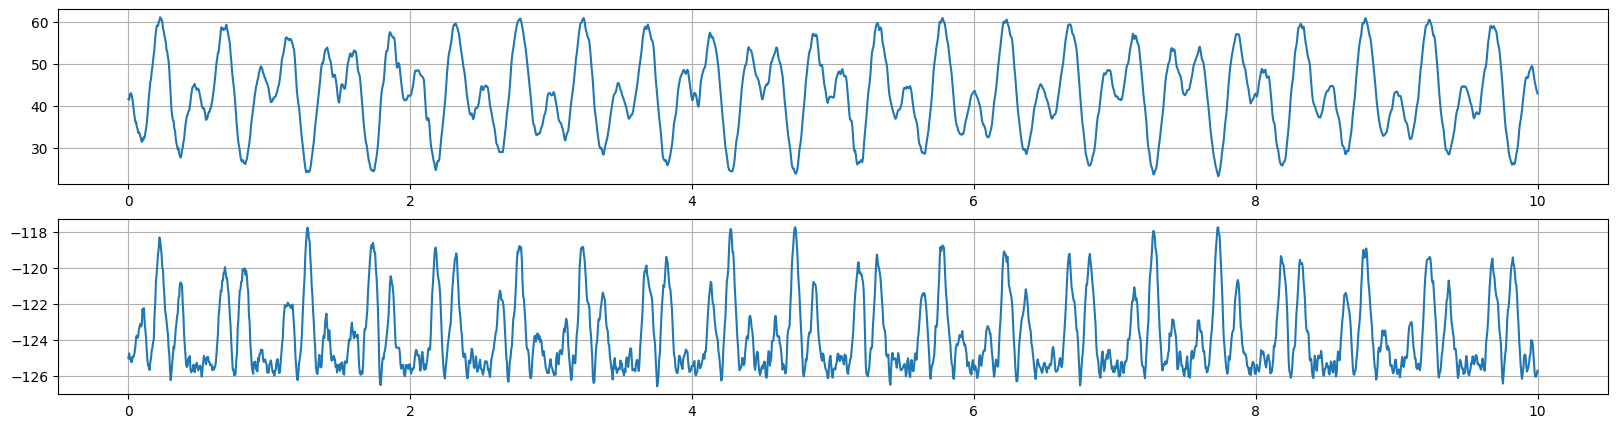

In [24]:
import math
fig, ax1 = plt.subplots(2, 1, figsize=(20, 5))
# ax1 = plt.axes()
ax1[0].plot(t1, data2[..., 1, 51]) # 33, 67
# ax1[0].plot(t1, data2[..., 1, 50])
ax1[0].grid(True)

ax1[1].plot(t1, -data2[..., 0, -1])
# ax1.set_xlabel("Time ($s$)")
# ax1.set_ylabel("Y position ($m$)")
ax1[1].grid(True)

plt.show()

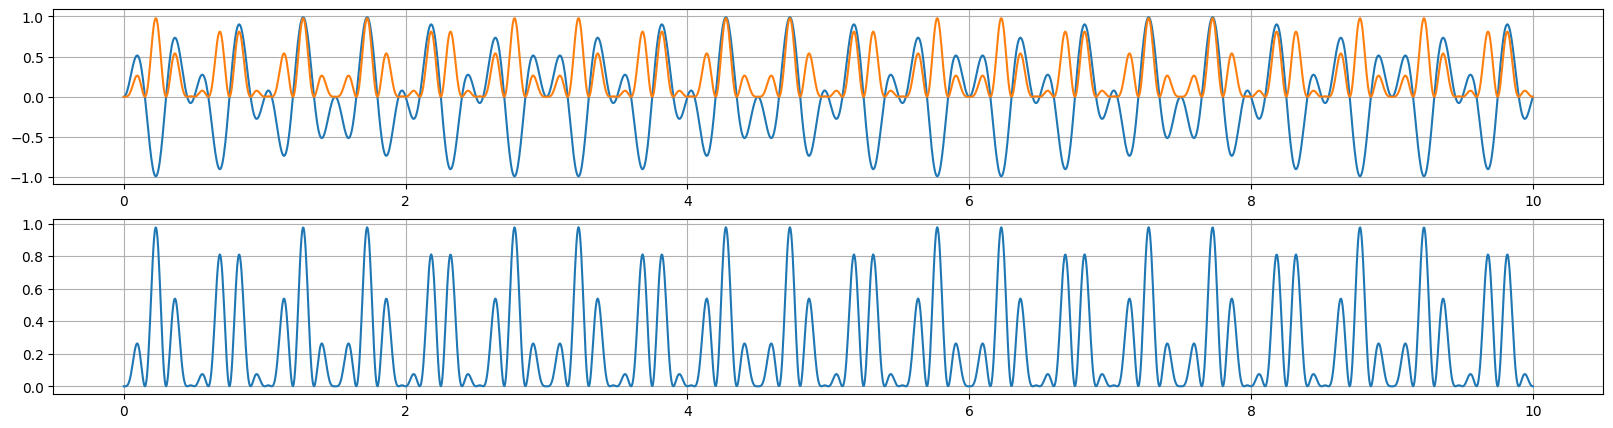

In [25]:
example = np.sin(t1 * (2 * np.pi)/0.3) * np.sin(t1 * (2 * np.pi)/1.0) * 1

fig, ax1 = plt.subplots(2, 1, figsize=(20, 5))
ax1[0].plot(t1, example) # 33, 67
ax1[0].plot(t1, example**2)
ax1[0].grid(True)

ax1[1].plot(t1, example**2)
ax1[1].grid(True)

plt.show()